In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_sql(
    "SELECT * FROM readings",
    "sqlite:///../simulator/sensor_data.db"
)

df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df.shape)
df.head()

(13932, 7)


,id,timestamp,room,sensor,value,unit,anomaly_injected
0,1,2026-05-25 19:47:56.454670+00:00,living_room,temperature,45.23,C,1
1,2,2026-05-25 19:47:56.454670+00:00,living_room,humidity,54.95,%,0
2,3,2026-05-25 19:47:56.454670+00:00,living_room,motion,0.00,bool,0
3,4,2026-05-25 19:47:56.454670+00:00,living_room,power,316.61,W,0
4,5,2026-05-25 19:47:56.454670+00:00,bedroom,temperature,23.49,C,0


In [2]:
print(df.dtypes)
print("\nValue counts per sensor:")
print(df['sensor'].value_counts())
print("\nAnomaly breakdown:")
print(df['anomaly_injected'].value_counts())
print(f"\nAnomaly rate: {df['anomaly_injected'].mean()*100:.2f}%")

id                                int64
timestamp           datetime64[us, UTC]
room                                str
sensor                              str
value                           float64
unit                                str
anomaly_injected                  int64
dtype: object

Value counts per sensor:
sensor
temperature    3483
humidity       3483
motion         3483
power          3483
Name: count, dtype: int64

Anomaly breakdown:
anomaly_injected
0    13208
1      724
Name: count, dtype: int64

Anomaly rate: 5.20%


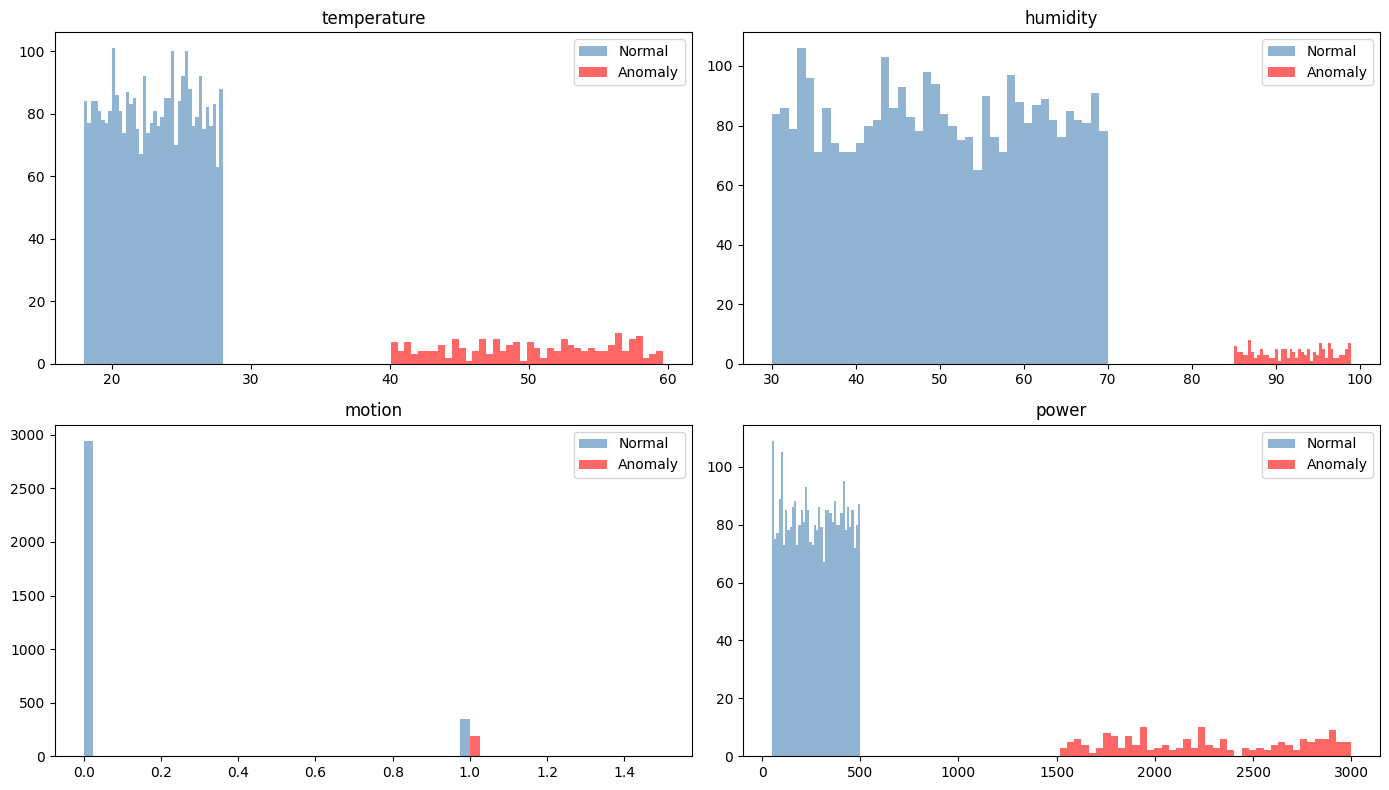

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sensors = ['temperature', 'humidity', 'motion', 'power']

for ax, sensor in zip(axes.flat, sensors):
    data = df[df['sensor'] == sensor]
    normal = data[data['anomaly_injected'] == 0]['value']
    anomaly = data[data['anomaly_injected'] == 1]['value']
    
    ax.hist(normal, bins=40, alpha=0.6, label='Normal', color='steelblue')
    ax.hist(anomaly, bins=40, alpha=0.6, label='Anomaly', color='red')
    ax.set_title(sensor)
    ax.legend()

plt.tight_layout()
plt.savefig('eda_distributions.png')
plt.show()

In [4]:
df_wide = df.pivot_table(
    index=['timestamp', 'room'],
    columns='sensor',
    values='value',
    aggfunc='first'
).reset_index()

labels = df.groupby(['timestamp', 'room'])['anomaly_injected'].max().reset_index()
df_wide = df_wide.merge(labels, on=['timestamp', 'room'])

df_wide.columns.name = None
df_wide = df_wide.ffill()

print(df_wide.shape)
df_wide.head()

(4647, 7)


,timestamp,room,humidity,motion,power,temperature,anomaly_injected
0,2026-05-25 19:47:56.454670+00:00,bedroom,34.17,NaN,NaN,23.49,0
1,2026-05-25 19:47:56.454670+00:00,living_room,54.95,0.0,316.61,45.23,1
2,2026-05-25 19:47:56.457189+00:00,bedroom,54.95,0.0,489.32,45.23,0
3,2026-05-25 19:47:56.457189+00:00,kitchen,31.77,0.0,489.32,25.22,0
4,2026-05-25 19:47:56.457755+00:00,kitchen,31.77,0.0,229.04,25.22,0


In [5]:
df_wide = df_wide.sort_values(['room', 'timestamp'])

df_wide['hour'] = df_wide['timestamp'].dt.hour

df_wide['temp_diff'] = df_wide.groupby('room')['temperature'].diff().fillna(0)
df_wide['power_diff'] = df_wide.groupby('room')['power'].diff().fillna(0)

df_wide['temp_rolling_mean'] = (
    df_wide.groupby('room')['temperature']
    .transform(lambda x: x.rolling(5, min_periods=1).mean())
)
df_wide['temp_deviation'] = df_wide['temperature'] - df_wide['temp_rolling_mean']

print(df_wide.columns.tolist())
df_wide.head()

['timestamp', 'room', 'humidity', 'motion', 'power', 'temperature', 'anomaly_injected', 'hour', 'temp_diff', 'power_diff', 'temp_rolling_mean', 'temp_deviation']


,timestamp,room,humidity,motion,power,temperature,anomaly_injected,hour,temp_diff,power_diff,temp_rolling_mean,temp_deviation
0,2026-05-25 19:47:56.454670+00:00,bedroom,34.17,NaN,NaN,23.49,0,19,0.00,0.00,23.490,0.000
2,2026-05-25 19:47:56.457189+00:00,bedroom,54.95,0.0,489.32,45.23,0,19,21.74,0.00,34.360,10.870
5,2026-05-25 19:47:57.458377+00:00,bedroom,66.75,0.0,407.93,20.11,0,19,-25.12,-81.39,29.610,-9.500
8,2026-05-25 19:47:58.460584+00:00,bedroom,60.97,0.0,70.15,19.17,0,19,-0.94,-337.78,27.000,-7.830
11,2026-05-25 19:47:59.462445+00:00,bedroom,64.67,0.0,443.74,20.46,0,19,1.29,373.59,25.692,-5.232


In [6]:
feature_cols = [
    'temperature', 'humidity', 'motion', 'power',
    'hour', 'temp_diff', 'power_diff', 'temp_deviation'
]

df_wide[feature_cols + ['anomaly_injected']].to_csv('features.csv', index=False)
print("Saved features.csv")
print(df_wide[feature_cols].describe())

Saved features.csv
       temperature     humidity       motion        power         hour  \
count  4647.000000  4647.000000  4646.000000  4646.000000  4647.000000   
mean     24.604467    51.887385     0.157124   373.502045    19.366473   
std       7.150991    14.224247     0.363957   466.285664     0.481893   
min      18.000000    30.010000     0.000000    50.190000    19.000000   
25%      20.620000    40.900000     0.000000   164.470000    19.000000   
50%      23.400000    50.560000     0.000000   285.515000    19.000000   
75%      25.880000    61.440000     0.000000   403.645000    20.000000   
max      59.620000    98.990000     1.000000  2999.200000    20.000000   

         temp_diff   power_diff  temp_deviation  
count  4647.000000  4647.000000     4647.000000  
mean     -0.001481    -0.079098       -0.008317  
std       9.274114   655.364702        6.313764  
min     -39.680000 -2861.810000      -22.828000  
25%      -2.660000  -144.520000       -2.985000  
50%       0.00